# LLM-MOBO for Rb₃BiI₆ Perovskite Synthesis Final

**Objectives:**
- **Coverage**: Maximize surface coverage (0-1)
- **Uniformity**: Minimize non-uniformity (lower is better)
- **Phase Purity**: Maximize phase purity (higher is better)

**Process Parameters:**
- Spin Speed [rpm]: 2500-5000
- Precursor Concentration [mol/L]: 0.1-0.8
- Annealing Temperature [°C]: 150-320
- Solvent Ratio: 1-3
- Solute Ratio: 2.8-3.2 (step:0.2)

In [2]:
import numpy as np
import pandas as pd
import random
import torch
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from botorch.models import SingleTaskGP, ModelListGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.multi_objective.monte_carlo import qNoisyExpectedHypervolumeImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning
from botorch.utils.multi_objective.pareto import is_non_dominated

from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.priors import LogNormalPrior
from gpytorch.mlls import ExactMarginalLogLikelihood
import gpytorch

from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")

In [3]:
# Utility functions for normalization and discretization
def x_normalizer(X, var_array):
    """Normalize parameters to [0,1] range"""
    def max_min_scaler(x, x_max, x_min):
        return (x-x_min)/(x_max-x_min)
    x_norm = []
    for x in X:
        x_norm.append([max_min_scaler(x[i], max(var_array[i]), min(var_array[i])) 
                      for i in range(len(x))])
    return x_norm

def x_denormalizer(x_norm, var_array):
    """Convert normalized parameters back to original scale"""
    def max_min_rescaler(x, x_max, x_min):
        return x*(x_max-x_min)+x_min
    x_original = []
    for x in x_norm:
        x_original.append([max_min_rescaler(x[i], max(var_array[i]), min(var_array[i])) 
                          for i in range(len(x))])
    return x_original

def get_closest_array(suggested_x, var_list):
    """Snap suggested parameters to discrete grids"""
    def get_closest_value(given_value, array_list):
        return min(array_list, key=lambda x: abs(x - given_value))
    
    modified_array = []
    for x in suggested_x:
        modified_array.append([get_closest_value(x[i], var_list[i]) for i in range(len(x))])
    return np.array(modified_array)

In [4]:

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# Device setup
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

# Define parameter ranges
var_array = [
    np.arange(2500, 5500, 500, dtype=float),      # Spin Speed [rpm]
    np.round(np.arange(0.1, 0.9, 0.1), 2),      # Concentration [mol/L] 
    np.arange(150, 330, 10, dtype=float),       # Annealing Temp [°C]
    np.arange(1, 4, 1, dtype=float),            # Solvent Ratio
    np.round(np.arange(2.8, 3.3, 0.2), 2)      # Solute Ratio
]

x_labels = ["Spin Speed [rpm]", "Precursor Concentration [mol/L]", 
           "Annealing Temperature [°C]", "Solvent Ratio", "Solute Ratio"]
y_labels = ["coverage", "uniformity", "phase_purity"]
objective_names = ['Coverage', 'Uniformity', 'Phase Purity']

Using device: cpu


In [5]:
# Load experimental data
df = pd.DataFrame([
    [0, 3000, 0.5, 200, 1, 3, 0.956, 1.049951401, 0.82728377],
    [1, 3000, 0.5, 200, 1, 3, 0.962, 1.169072348, 0.866783246],
    [2, 3000, 0.5, 200, 1, 3, 0.971, 1.007030926, 0.916281896],
    [3, 3500, 0.6, 240, 1, 3, 0.777, 1.00267491, 0.812187417],
    [4, 3500, 0.6, 240, 1, 3, 0.901, 0.976901665, 0.890359476],
    [5, 3500, 0.6, 240, 1, 3, 0.321, 0.999770457, 0.917666337],
    [6, 4000, 0.7, 280, 1, 3, 0.885, 0.781329185, 0.66254288],
    [7, 4000, 0.7, 280, 1, 3, 0.986, 0.714201058, 0.826481264],
    [8, 4000, 0.7, 280, 1, 3, 0.936, 0.947498682, 0.889186299],
    [9, 2500, 0.3, 180, 1, 3, 0.975, 0.917613814, 0.858170725],
    [10, 2500, 0.3, 180, 1, 3, 0.975, 0.958664586, 0.89078723],
    [11, 2500, 0.3, 180, 1, 3, 0.975, 1.078594421, 0.917345259],
    [12, 4500, 0.8, 320, 1, 3, 0.983, 0.853385591, 0.634970619],
    [13, 4500, 0.8, 320, 1, 3, 0.974, 0.830085909, 0.764950994],
    [14, 4500, 0.8, 320, 1, 3, 1.004, 0.757956056, 0.785094619],
    [15, 5000, 0.4, 170, 2, 3, 0.949, 0.736480808, 0.503609871],
    [16, 5000, 0.4, 170, 2, 3, 0.748, 1.051376525, 0.502791307],
    [17, 5000, 0.4, 170, 2, 3, 0.552, 1.296851719, 0.411507317],
    [18, 3000, 0.6, 250, 1, 3.2, 0.981, 1.067954088, 0.799362543],
    [19, 3000, 0.6, 250, 1, 3.2, 0.98, 1.214273575, 0.829704728],
    [20, 3000, 0.6, 250, 1, 3.2, 0.964, 1.207912353, 0.879228912],
    [21, 4000, 0.5, 290, 3, 2.8, 0.936, 1.059860231, 0.866598017],
    [22, 4000, 0.5, 290, 3, 2.8, 0.597, 1.351926625, 0.875095339],
    [23, 4000, 0.5, 290, 3, 2.8, 0.11, 2.540441208, 0.53883167],
    [24, 2500, 0.7, 220, 1, 3, 0.938, 0.979524666, 0.663436084],
    [25, 2500, 0.7, 220, 1, 3, 0.945, 1.099893097, 0.819420601],
    [26, 2500, 0.7, 220, 1, 3, 0.935, 1.096153483, 0.85691591],
    [27, 4500, 0.3, 260, 2, 3, 0.979, 1.033150645, 0.887218589],
    [28, 4500, 0.3, 260, 2, 3, 0.918, 1.031152158, 0.806529909],
    [29, 4500, 0.3, 260, 2, 3, 0.958, 1.099666435, 0.604749821],
    [30, 3500, 0.4, 280, 1, 3.2, 0.974, 1.137132745, 0.727164282],
    [31, 3500, 0.4, 280, 1, 3.2, 0.955, 1.302505653, 0.82439861],
    [32, 3500, 0.4, 280, 1, 3.2, 0.987, 1.120476357, 0.755093405],
    [33, 5000, 0.6, 300, 3, 2.8, 0.983, 1.103733059, 0.496000689],
    [34, 5000, 0.6, 300, 3, 2.8, 0.977, 1.033104055, 0.519372372],
    [35, 5000, 0.6, 300, 3, 2.8, 0.967, 1.057566333, 0.493095039],
    [36, 2500, 0.5, 190, 3, 3, 0.950459102, 1.03943042, 0.742608721],
    [37, 2500, 0.5, 190, 3, 3, 0.983436225, 1.166054857, 0.515609939],
    [38, 2500, 0.5, 190, 3, 3, 0.988755374, 1.050624505, 0.506600238],
    [39, 2500, 0.8, 170, 2, 3, 0.933664382, 1.019324855, 0.401434201],
    [40, 2500, 0.8, 170, 2, 3, 0.986445208, 1.139598294, 0.567126736],
    [41, 2500, 0.8, 170, 2, 3, 0.963795558, 1.12504793, 0.343474852],
    [42, 3500, 0.7, 200, 3, 3, 0.973241843, 0.872404352, 0.234267795],
    [43, 3500, 0.7, 200, 3, 3, 0.959354226, 1.007814339, 0.309682485],
    [44, 3500, 0.7, 200, 3, 3, 0.963740041, 0.980571343, 0.251327091],
    [45, 3000, 0.5, 160, 2, 3.2, 0.964734286, 0.881626209, 0.244426927],
    [46, 3000, 0.5, 160, 2, 3.2, 0.96877014, 1.016796103, 0.25463448],
    [47, 3000, 0.5, 160, 2, 3.2, 0.979767352, 0.985191617, 0.266485294],
    [48, 3000, 0.5, 280, 3, 3, 0.954528282, 0.966784534, 0.263892132],
    [49, 3000, 0.5, 280, 3, 3, 0.952673213, 1.063840936, 0.316168181],
    [50, 3000, 0.5, 280, 3, 3, 0.973135875, 1.097774456, 0.442425562],
    [51, 4000, 0.4, 250, 1, 3, 0.985961834, 0.958350722, 0.906158521],
    [52, 4000, 0.4, 250, 1, 3, 0.984291471, 0.905942791, 0.948295799],
    [53, 4000, 0.4, 250, 1, 3, 0.958413462, 0.915447458, 0.958941236],
    [54, 4000, 0.4, 250, 1, 3, 0.978003198, 0.824652731, 0.951734602],
    [55, 4000, 0.4, 250, 1, 3, 0.991059492, 1.038675538, 0.961301544],
    [56, 4000, 0.4, 250, 1, 3, 0.961011187, 1.036959964, 0.928347421],
    [57, 4500, 0.5, 190, 1, 3.2, 0.98485103, 0.865122402, 0.955809444],
    [58, 4500, 0.5, 190, 1, 3.2, 0.959109043, 0.845045857, 0.906806494],
    [59, 4500, 0.5, 190, 1, 3.2, 0.942716994, 1.114257893, 0.840624248],
    [60, 4000, 0.2, 320, 2, 2.8, 0.984203893, 0.956458929, 0.853946422],
    [61, 4000, 0.2, 320, 2, 2.8, 0.969456021, 1.173806157, 0.748432495],
    [62, 4000, 0.2, 320, 2, 2.8, 0.984483815, 0.997082483, 0.877035924],
    [63, 3500, 0.2, 290, 1, 3, 0.980438336, 0.742641255, 0.949148812],
    [64, 3500, 0.2, 290, 1, 3, 0.973758201, 0.733055566, 0.959376544],
    [65, 3500, 0.2, 290, 1, 3, 0.987847222, 0.665380058, 0.967809424],
    [66, 4500, 0.2, 170, 1, 3, 0.943850839, 1.087844106, 0.868725254],
    [67, 4500, 0.2, 170, 1, 3, 0.953550812, 1.133707273, 0.876874163],
    [68, 4500, 0.2, 170, 1, 3, 0.96545295, 0.727722439, 0.982288767],
    [69, 5000, 0.6, 300, 2, 3, 0.965857672, 0.764288762, 0.649880781],
    [70, 5000, 0.6, 300, 2, 3, 0.988766892, 0.845904334, 0.280549053],
    [71, 5000, 0.6, 300, 2, 3, 0.972902974, 0.830524252, 0.560356257],
    [72, 5000, 0.1, 310, 2, 3, 0.133191416, 3.366973073, 0.811270526],
    [73, 5000, 0.1, 310, 2, 3, 0.062093759, 3.431180916, 0.513991005],
    [74, 5000, 0.1, 310, 2, 3, 0.05302433, 2.880623129, 0.500530897],
    [75, 2500, 0.5, 320, 1, 2.8, 0.977162649, 0.849147069, 0.89810816],
    [76, 2500, 0.5, 320, 1, 2.8, 0.960995645, 0.891666129, 0.938336829],
    [77, 2500, 0.5, 320, 1, 2.8, 0.962892141, 0.817820622, 0.942749066],
    [78, 4000, 0.3, 300, 1, 2.8, 0.920429479, 0.866406793, 0.955151669],
    [79, 4000, 0.3, 300, 1, 2.8, 0.980292793, 0.904686265, 0.944210033],
    [80, 4000, 0.3, 300, 1, 2.8, 0.905645295, 1.105849729, 0.898085728],
    [81, 3000, 0.1, 320, 1, 2.8, 0.736392, 1.328531993, 0.812534625],
    [82, 3000, 0.1, 320, 1, 2.8, 0.553310546, 1.54402098, 0.826864105],
    [83, 3000, 0.1, 320, 1, 2.8, 0.470861486, 1.645806097, 0.846945602],
    [84, 4000, 0.4, 320, 1, 2.8, 0.970682124, 0.735477753, 0.949600772],
    [85, 4000, 0.4, 320, 1, 2.8, 0.957373491, 0.79711631, 0.959388963],
    [86, 4000, 0.4, 320, 1, 2.8, 0.948446615, 0.676143245, 0.96172209],
    [87, 2500, 0.1, 280, 1, 2.8, 0.898397427, 0.995900949, 0.931603648],
    [88, 2500, 0.1, 280, 1, 2.8, 0.906614898, 1.199210217, 0.928351561],
    [89, 2500, 0.1, 280, 1, 2.8, 0.886882328, 0.922537059, 0.929093131],
], columns=["#sample"] + x_labels + y_labels)

print(f"✓ Loaded {len(df)} experimental data points")
print(f"Parameters: {x_labels}")
print(f"Objectives: {y_labels}")
display(df.head())

✓ Loaded 90 experimental data points
Parameters: ['Spin Speed [rpm]', 'Precursor Concentration [mol/L]', 'Annealing Temperature [°C]', 'Solvent Ratio', 'Solute Ratio']
Objectives: ['coverage', 'uniformity', 'phase_purity']


,#sample,Spin Speed [rpm],Precursor Concentration [mol/L],Annealing Temperature [°C],Solvent Ratio,Solute Ratio,coverage,uniformity,phase_purity
0,0,3000,0.5,200,1,3.0,0.956,1.049951,0.827284
1,1,3000,0.5,200,1,3.0,0.962,1.169072,0.866783
2,2,3000,0.5,200,1,3.0,0.971,1.007031,0.916282
3,3,3500,0.6,240,1,3.0,0.777,1.002675,0.812187
4,4,3500,0.6,240,1,3.0,0.901,0.976902,0.890359


In [6]:
# Data preprocessing
print("=== Data Preprocessing ===")

# Prepare training data
X_train = df[x_labels].values
Y_train = df[y_labels].values

print(f"Training data: X shape {X_train.shape}, Y shape {Y_train.shape}")

# Handle objective directions: convert uniformity (minimize) to maximize by negation
Y_processed = Y_train.copy()
Y_processed[:, 1] = -Y_processed[:, 1]  # Negate uniformity for maximization

# Normalize inputs to [0, 1] and convert to tensors
X_normalized = x_normalizer(X_train, var_array)
X_tensor = torch.FloatTensor(X_normalized).to(device)
Y_tensor = torch.FloatTensor(Y_processed).to(device)

=== Data Preprocessing ===
Training data: X shape (90, 5), Y shape (90, 3)


In [7]:
# Gaussian Process model fitting
print("=== Fitting Gaussian Process Models ===")

def fit_gp_models(X, Y, kernel_fn=None, noise_priors=None):
    """
    Fits GP models following MOBO-Kit implementation.
    One GP per objective with Matern kernel and custom noise priors.
    """
    # Input validation
    X_min, X_max = X.min(), X.max()
    if X_min < 0.0 or X_max > 1.0:
        warnings.warn(f"X not normalized to [0,1]: [{X_min:.4f}, {X_max:.4f}]", UserWarning)
    
    models = []
    D, M = X.shape[1], Y.shape[1]
    
    # Handle kernel function
    if kernel_fn is None:
        kernel_fns = [lambda d: MaternKernel(nu=2.5, ard_num_dims=d)] * M
    elif callable(kernel_fn):
        kernel_fns = [kernel_fn] * M
    else:
        raise TypeError("kernel_fn must be callable or None")
    
    # Handle noise priors
    if noise_priors is None:
        noise_priors_list = [None] * M
    elif isinstance(noise_priors, list):
        if len(noise_priors) != M:
            raise ValueError(f"noise_priors length ({len(noise_priors)}) must match M={M}")
        noise_priors_list = noise_priors
    else:
        noise_priors_list = [noise_priors] * M
    
    # Move priors to device
    for k in range(M):
        p = noise_priors_list[k]
        if p is not None and hasattr(p, "to"):
            noise_priors_list[k] = p.to(X.device)
    
    # Fit one GP per objective
    for j in range(M):
        base_kernel = kernel_fns[j](D)
        covar_module = ScaleKernel(base_kernel)
        
        pj = noise_priors_list[j]
        likelihood = gpytorch.likelihoods.GaussianLikelihood(
            noise_prior=pj,
            noise_constraint=gpytorch.constraints.GreaterThan(1e-3),
        )
        
        gp = SingleTaskGP(
            X, Y[:, j:j+1],
            covar_module=covar_module, 
            likelihood=likelihood,
            outcome_transform=Standardize(m=1)
        )
        
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        
        # Robust fitting with retry
        try:
            fit_gpytorch_mll(mll)
        except Exception as e:
            print(f"[GP {j}] First fit failed ({e}), retrying...")
            try:
                gp.likelihood.noise_covar.register_constraint(
                    "raw_noise", gpytorch.constraints.GreaterThan(1e-2)
                )
                with torch.no_grad():
                    gp.likelihood.noise = torch.as_tensor(1e-2, device=X.device, dtype=X.dtype)
                fit_gpytorch_mll(mll)
            except Exception as e2:
                print(f"[GP {j}] Retry failed ({e2}), using initial hyperparameters")
        
        models.append(gp)
    
    return ModelListGP(*models)

# Define noise priors and kernel function
noise_priors = [
    LogNormalPrior(-3.0, 0.5),  # Coverage
    LogNormalPrior(-3.0, 0.5),  # Uniformity (neg)
    LogNormalPrior(-3.0, 0.5),  # Phase Purity
]


kernel_fn = lambda d: MaternKernel(nu=2.5, ard_num_dims=d)

# Fit the model
model = fit_gp_models(X_tensor, Y_tensor, kernel_fn=kernel_fn, noise_priors=noise_priors)
print("✓ GP models fitted successfully")

=== Fitting Gaussian Process Models ===
✓ GP models fitted successfully


=== Model Validation & Diagnostics ===


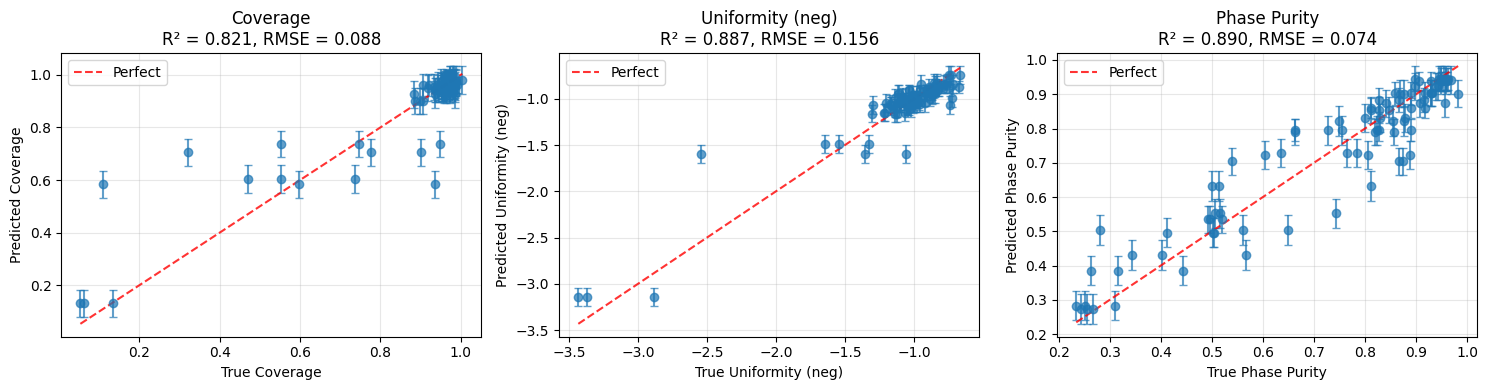


Model Performance:
Coverage: R² = 0.8210, RMSE = 0.0879
Uniformity (neg): R² = 0.8868, RMSE = 0.1563
Phase Purity: R² = 0.8905, RMSE = 0.0744

✓ Model validation complete


In [8]:
# Model validation and diagnostics
print("=== Model Validation & Diagnostics ===")

def posterior_report(model, X):
    """Get posterior predictions with uncertainty quantification"""
    with torch.no_grad():
        posterior = model.posterior(X)
        pred_mean_t = posterior.mean
        pred_std_t = torch.sqrt(posterior.variance)
    
    pred_mean = pred_mean_t.cpu().numpy()
    pred_std = pred_std_t.cpu().numpy()
    return pred_mean, pred_std

def compute_metrics(true_Y, pred_mean, objective_names):
    """Calculate R² and RMSE for each objective"""
    metrics = []
    for j, obj_name in enumerate(objective_names):
        true_vals = true_Y[:, j]
        pred_vals = pred_mean[:, j]
        
        r2 = r2_score(true_vals, pred_vals)
        rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
        
        metrics.append({
            'objective': obj_name,
            'r2': round(r2, 4),
            'rmse': round(rmse, 4)
        })
    
    return pd.DataFrame(metrics)

def plot_parity(Y_true, Y_pred, Y_std, objective_names):
    """Create parity plots for model validation"""
    n_obj = len(objective_names)
    fig, axes = plt.subplots(1, n_obj, figsize=(5*n_obj, 4))
    if n_obj == 1:
        axes = [axes]
    
    for j, (ax, obj_name) in enumerate(zip(axes, objective_names)):
        true_vals = Y_true[:, j]
        pred_vals = Y_pred[:, j]
        
        # Calculate metrics
        r2 = r2_score(true_vals, pred_vals)
        rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
        
        # Plot with error bars
        ax.errorbar(true_vals, pred_vals, yerr=Y_std[:, j], fmt='o', alpha=0.7, capsize=3)
        
        # Perfect prediction line
        min_val = min(true_vals.min(), pred_vals.min())
        max_val = max(true_vals.max(), pred_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect')
        
        ax.set_xlabel(f'True {obj_name}')
        ax.set_ylabel(f'Predicted {obj_name}')
        ax.set_title(f'{obj_name}\nR² = {r2:.3f}, RMSE = {rmse:.3f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Get predictions and calculate metrics
pred_mean, pred_std = posterior_report(model, X_tensor)
Y_np = Y_tensor.cpu().numpy()

# Create parity plots
fig_parity = plot_parity(Y_np, pred_mean, pred_std, ['Coverage', 'Uniformity (neg)', 'Phase Purity'])
# plt.savefig('model_parity_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate and display metrics
metrics_df = compute_metrics(Y_np, pred_mean, ['Coverage', 'Uniformity (neg)', 'Phase Purity'])
print("\nModel Performance:")
for _, row in metrics_df.iterrows():
    print(f"{row['objective']}: R² = {row['r2']:.4f}, RMSE = {row['rmse']:.4f}")

print("\n✓ Model validation complete")

In [71]:
def load_plt_setting():
    plt.style.use('seaborn-v0_8-white')
    mpl.rcParams['font.sans-serif'] = "Arial"
    mpl.rcParams['font.family'] = "sans-serif"
    mpl.rcParams['axes.linewidth'] = 2
    font = {'size': 32}
    mpl.rc('font', **font)
    mpl.rcParams['xtick.major.pad']='8'
    mpl.rcParams['ytick.major.pad']='8'
    plt.rcParams["font.weight"] = "normal"
    plt.rcParams["axes.labelweight"] = "normal"
    plt.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['axes.linewidth'] = 2

=== 5-Fold CV Parity Figures (Individual) ===


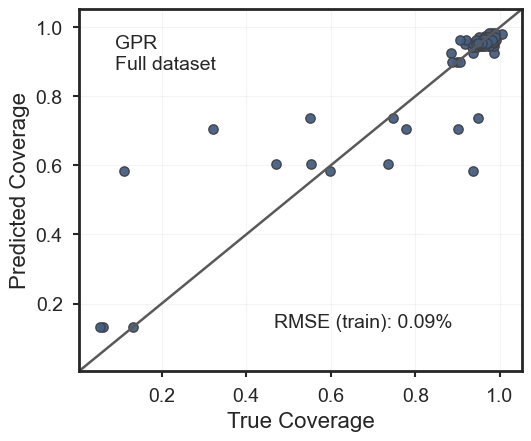

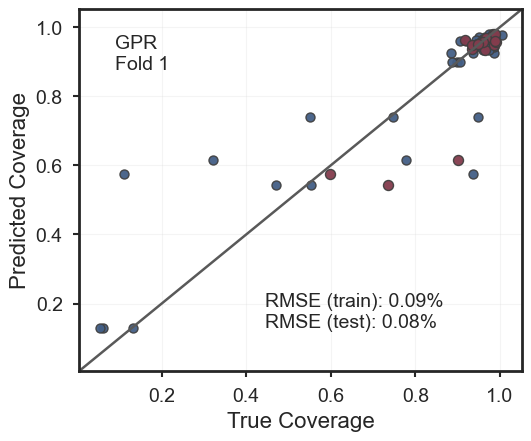

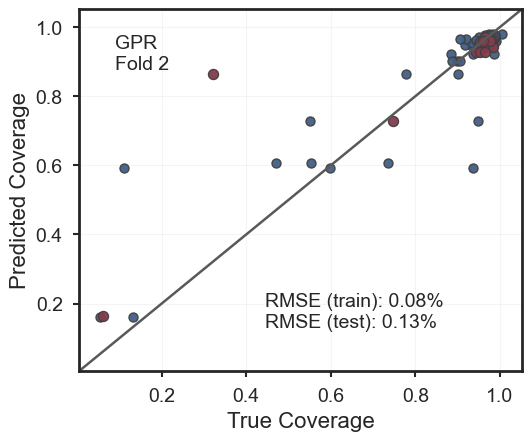

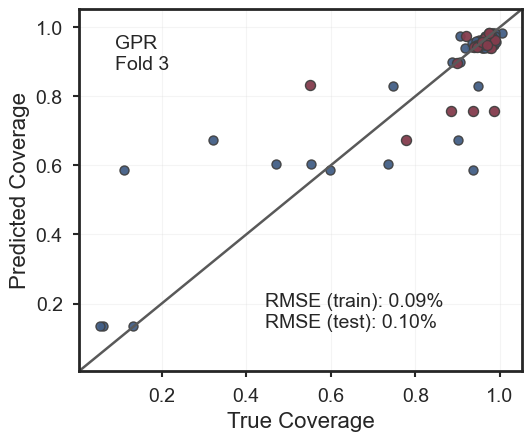

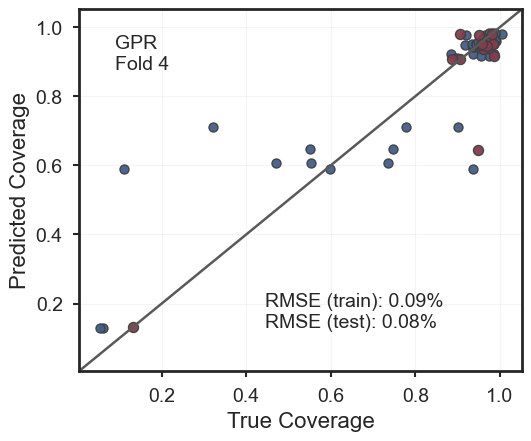

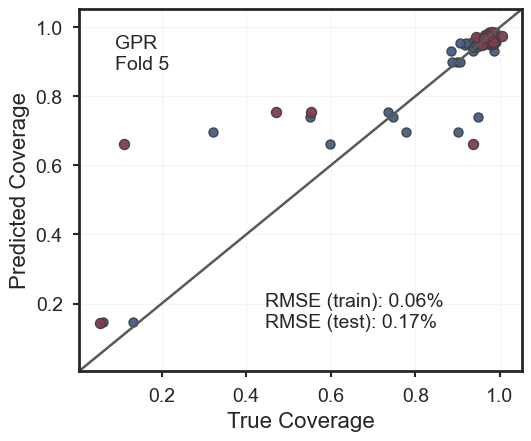

In [79]:
# 5-fold CV parity figures (individual files: a–f)
# a: full dataset fit, b–f: fold-wise train/test parity
print("=== 5-Fold CV Parity Figures (Individual) ===")

from sklearn.model_selection import KFold

objective_idx = 0  # 0=Coverage, 1=Uniformity, 2=Phase Purity
objective_name = ["Coverage", "Uniformity", "Phase Purity Proxy"][objective_idx]

# Convert back to original sign for display only (uniformity was negated for training)
display_sign = -1.0 if objective_idx == 1 else 1.0

X_all = X_tensor
Y_all = Y_tensor
n = X_all.shape[0]

def make_noise_priors():
    return [
        LogNormalPrior(-3.0, 0.5),
        LogNormalPrior(-3.0, 0.5),
        LogNormalPrior(-3.0, 0.5),
    ]

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# Full-data prediction (panel a)
with torch.no_grad():
    pred_full_mean, _ = posterior_report(model, X_all)

y_true_full = display_sign * Y_all[:, objective_idx].detach().cpu().numpy()
y_pred_full = display_sign * pred_full_mean[:, objective_idx]
rmse_full_train = rmse(y_true_full, y_pred_full)

# 5-fold results (panels b-f)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for fold_id, (train_idx, test_idx) in enumerate(kf.split(np.arange(n)), start=1):
    train_idx_t = torch.tensor(train_idx, device=X_all.device)
    test_idx_t = torch.tensor(test_idx, device=X_all.device)

    X_tr, Y_tr = X_all[train_idx_t], Y_all[train_idx_t]
    X_te, Y_te = X_all[test_idx_t], Y_all[test_idx_t]

    fold_model = fit_gp_models(
        X_tr,
        Y_tr,
        kernel_fn=kernel_fn,
        noise_priors=make_noise_priors(),
    )

    with torch.no_grad():
        pred_tr_mean, _ = posterior_report(fold_model, X_tr)
        pred_te_mean, _ = posterior_report(fold_model, X_te)

    y_tr_true = display_sign * Y_tr[:, objective_idx].detach().cpu().numpy()
    y_te_true = display_sign * Y_te[:, objective_idx].detach().cpu().numpy()
    y_tr_pred = display_sign * pred_tr_mean[:, objective_idx]
    y_te_pred = display_sign * pred_te_mean[:, objective_idx]

    cv_results.append({
        "fold": fold_id,
        "y_tr_true": y_tr_true,
        "y_tr_pred": y_tr_pred,
        "y_te_true": y_te_true,
        "y_te_pred": y_te_pred,
        "rmse_tr": rmse(y_tr_true, y_tr_pred),
        "rmse_te": rmse(y_te_true, y_te_pred),
    })

# Shared axis limits across all 6 figures
all_true = [y_true_full]
all_pred = [y_pred_full]
for r in cv_results:
    all_true.extend([r["y_tr_true"], r["y_te_true"]])
    all_pred.extend([r["y_tr_pred"], r["y_te_pred"]])

vmin = min(np.min(np.concatenate(all_true)), np.min(np.concatenate(all_pred)))
vmax = max(np.max(np.concatenate(all_true)), np.max(np.concatenate(all_pred)))
pad = 0.05 * (vmax - vmin + 1e-12)
vmin, vmax = vmin - pad, vmax + pad

letters = list("abcdef")
train_color = "#435F86" 
test_color = "#843C4D"   
line_color = "0.35"

# Use local plotting style to avoid global oversized fonts from prior cells
with plt.rc_context({
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
}):
    # Figure a: full dataset
    load_plt_setting()
    fig, ax = plt.subplots(figsize=(5.2, 4.3), constrained_layout=True)
    ax.scatter(y_true_full, y_pred_full, s=45, c=train_color, edgecolor="0.25", alpha=0.95)
    ax.plot([vmin, vmax], [vmin, vmax], "-", color=line_color, lw=1.8)
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_xlabel(f"True {objective_name}")
    ax.set_ylabel(f"Predicted {objective_name}")
    ax.text(0.08, 0.93, "GPR\nFull dataset", transform=ax.transAxes, va="top", fontsize=14)
    ax.text(0.44, 0.12, f"RMSE (train): {rmse_full_train:.2f}%", transform=ax.transAxes, fontsize=14)
    # ax.text(-0.16, 1.03, letters[0], transform=ax.transAxes, fontsize=22, fontweight="bold")
    ax.grid(alpha=0.20)
    ax.tick_params(axis='x', labelsize=14, width=1.5, length=4, direction='out')
    ax.tick_params(axis='y', labelsize=14, width=1.5, length=4, direction='out')
    fig.savefig('/Users/shengfang/Desktop/TRI/Rb3BiI6/Figure/surrogate_coverage_full.png', dpi=300, bbox_inches='tight')
    fig.savefig('/Users/shengfang/Desktop/TRI/Rb3BiI6/Figure/surrogate_coverage_full.svg', dpi=300, bbox_inches='tight')
    plt.show()

    # Figures b-f: folds 1-5
    for i, r in enumerate(cv_results, start=1):
        fig, ax = plt.subplots(figsize=(5.2, 4.3), constrained_layout=True)
        ax.scatter(r["y_tr_true"], r["y_tr_pred"], s=42, c=train_color, edgecolor="0.25", alpha=0.95)
        ax.scatter(r["y_te_true"], r["y_te_pred"], s=52, c=test_color, edgecolor="0.25", alpha=0.95)
        ax.plot([vmin, vmax], [vmin, vmax], "-", color=line_color, lw=1.8)
        ax.set_xlim(vmin, vmax)
        ax.set_ylim(vmin, vmax)
        ax.set_xlabel(f"True {objective_name}")
        ax.set_ylabel(f"Predicted {objective_name}")
        ax.text(0.08, 0.93, f"GPR\nFold {r['fold']}", transform=ax.transAxes, va="top", fontsize=14)
        ax.text(
            0.42,
            0.12,
            f"RMSE (train): {r['rmse_tr']:.2f}%\nRMSE (test): {r['rmse_te']:.2f}%",
            transform=ax.transAxes,
            fontsize=14,
        )
        # ax.text(-0.16, 1.03, letters[i], transform=ax.transAxes, fontsize=22, fontweight="bold")
        ax.grid(alpha=0.20)
        ax.tick_params(axis='x', labelsize=14, width=1.5, length=4, direction='out')
        ax.tick_params(axis='y', labelsize=14, width=1.5, length=4, direction='out')
        fig.savefig(f'/Users/shengfang/Desktop/TRI/Rb3BiI6/Figure/surrogate_coverage_{letters[i]}_fold{r["fold"]}.png', dpi=300, bbox_inches='tight')
        fig.savefig(f'/Users/shengfang/Desktop/TRI/Rb3BiI6/Figure/surrogate_coverage_{letters[i]}_fold{r["fold"]}.svg', dpi=300, bbox_inches='tight')
        plt.show()

In [9]:
# Pareto front analysis
print("=== Pareto Front Analysis ===")

def compute_ref_pareto_hv(Y_t, ref_point=None):
    """Compute Pareto front and hypervolume"""
    pareto_mask = is_non_dominated(Y_t)
    pareto_Y_t = Y_t[pareto_mask]
    
    if ref_point is None:
        ref_point = Y_t.min(dim=0)[0] - 0.01
    
    bd = FastNondominatedPartitioning(ref_point=ref_point, Y=pareto_Y_t)
    hv_val = bd.compute_hypervolume().item()
    
    return ref_point, pareto_Y_t, hv_val

# Find Pareto front
ref_point_t, pareto_Y_t, hv_val = compute_ref_pareto_hv(Y_tensor)
pareto_mask = is_non_dominated(Y_tensor)
pareto_X = X_tensor[pareto_mask]

print(f"Pareto front: {pareto_Y_t.shape[0]} out of {Y_tensor.shape[0]} points")
print(f"Current hypervolume: {hv_val:.4f}")
print("\nPareto front points (Coverage, -Uniformity, Phase Purity):")
print(pareto_Y_t.cpu().numpy())

print("✓ Pareto analysis complete")

=== Pareto Front Analysis ===
Pareto front: 4 out of 90 points
Current hypervolume: 2.0120

Pareto front points (Coverage, -Uniformity, Phase Purity):
[[ 1.004      -0.757956    0.7850946 ]
 [ 0.9910595  -1.0386755   0.96130157]
 [ 0.9878472  -0.66538006  0.96780944]
 [ 0.96545297 -0.72772247  0.9822888 ]]
✓ Pareto analysis complete


In [10]:
# Hypervolume improvement for BO/LLM-BO samples, excluding initialization round
print("=== Hypervolume Improvement (Excluding Initialization) ===")

n_init = 36  # Number of initialization samples
Y_init = Y_tensor[:n_init]
Y_new = Y_tensor[n_init:]

# Use the same reference point as in your analysis
ref_point = ref_point_t if 'ref_point_t' in globals() else Y_tensor.min(dim=0)[0] - 0.01

def compute_hv(Y, ref_point):
    bd = FastNondominatedPartitioning(ref_point=ref_point, Y=Y)
    return bd.compute_hypervolume().item()

hv_init = compute_hv(Y_init, ref_point)
hv_improvements = []
for i in range(Y_new.shape[0]):
    Y_with = torch.cat([Y_init, Y_new[i:i+1]], dim=0)
    hv_with = compute_hv(Y_with, ref_point)
    hv_improvements.append(hv_with - hv_init)

# Only assign to the BO/LLM-BO samples (not the initialization samples)
df_new = df.iloc[n_init:].copy()
df_new['hv_improvement'] = hv_improvements
display(df_new.sort_values('hv_improvement', ascending=False).head(10))

print("✓ Hypervolume improvement calculation complete")

=== Hypervolume Improvement (Excluding Initialization) ===


,#sample,Spin Speed [rpm],Precursor Concentration [mol/L],Annealing Temperature [°C],Solvent Ratio,Solute Ratio,coverage,uniformity,phase_purity,hv_improvement
65,65,3500,0.2,290,1,3.0,0.987847,0.665380,0.967809,0.187327
68,68,4500,0.2,170,1,3.0,0.965453,0.727722,0.982289,0.181362
86,86,4000,0.4,320,1,2.8,0.948447,0.676143,0.961722,0.154545
64,64,3500,0.2,290,1,3.0,0.973758,0.733056,0.959377,0.124480
85,85,4000,0.4,320,1,2.8,0.957373,0.797116,0.959389,0.114519
55,55,4000,0.4,250,1,3.0,0.991059,1.038676,0.961302,0.103353
57,57,4500,0.5,190,1,3.2,0.984851,0.865122,0.955809,0.102418
84,84,4000,0.4,320,1,2.8,0.970682,0.735478,0.949601,0.099226
53,53,4000,0.4,250,1,3.0,0.958413,0.915447,0.958941,0.099218
63,63,3500,0.2,290,1,3.0,0.980438,0.742641,0.949149,0.098948


✓ Hypervolume improvement calculation complete


In [13]:
print("=== Best Conditions for XRD Selection ===")
from itertools import product
# 1. Generate ALL feasible grid conditions, including tested samples
X_grid_phys = np.array(list(product(*var_array)), dtype=float)

# 2. Normalize grid
X_grid_norm = x_normalizer(X_grid_phys, var_array)
X_grid_tensor = torch.tensor(
    X_grid_norm,
    dtype=X_tensor.dtype,
    device=X_tensor.device
)

# 3. Predict all candidates
with torch.no_grad():
    posterior = model.posterior(X_grid_tensor)
    pred_mean = posterior.mean.cpu().numpy()
    pred_std = posterior.variance.sqrt().cpu().numpy()

# 4. Build table
candidate_df = pd.DataFrame(X_grid_phys, columns=x_labels)

candidate_df["pred_coverage"] = pred_mean[:, 0]
candidate_df["pred_uniformity"] = -pred_mean[:, 1]
candidate_df["pred_phase_purity"] = pred_mean[:, 2]

candidate_df["std_coverage"] = pred_std[:, 0]
candidate_df["std_uniformity"] = pred_std[:, 1]
candidate_df["std_phase_purity"] = pred_std[:, 2]

# 5. Mark whether condition was already tested
X_existing_phys = x_denormalizer(X_tensor.detach().cpu().numpy(), var_array)
X_existing_phys = get_closest_array(X_existing_phys, var_array)
existing_set = {tuple(row) for row in X_existing_phys}

candidate_df["tested_before"] = [
    tuple(row) in existing_set for row in X_grid_phys
]

# 6. Find predicted Pareto front
Y_pred_tensor = torch.tensor(
    np.column_stack([
        candidate_df["pred_coverage"].values,
        -candidate_df["pred_uniformity"].values,
        candidate_df["pred_phase_purity"].values,
    ]),
    dtype=X_tensor.dtype,
    device=X_tensor.device
)

pareto_mask = is_non_dominated(Y_pred_tensor).cpu().numpy()
pareto_df = candidate_df[pareto_mask].copy()

# 7. Sort for XRD-worthy samples:
# high phase purity first, then high uniformity, then low coverage
xrd_candidates = pareto_df.sort_values(
    ["pred_phase_purity", "pred_uniformity", "pred_coverage"],
    ascending=[False, True, False]
)

print(f"Predicted Pareto candidates: {len(xrd_candidates)}")
display(xrd_candidates.head(10))

=== Best Conditions for XRD Selection ===
Predicted Pareto candidates: 115


,Spin Speed [rpm],Precursor Concentration [mol/L],Annealing Temperature [°C],Solvent Ratio,Solute Ratio,pred_coverage,pred_uniformity,pred_phase_purity,std_coverage,std_uniformity,std_phase_purity,tested_before
6904,5000.0,0.3,260.0,1.0,3.0,0.531517,1.703387,0.954865,0.120440,0.267158,0.036815,False
5608,4500.0,0.3,260.0,1.0,3.0,0.957509,1.009238,0.954865,0.069624,0.164535,0.036814,False
4312,4000.0,0.3,260.0,1.0,3.0,0.969322,0.951344,0.954865,0.047616,0.091963,0.036815,False
3016,3500.0,0.3,260.0,1.0,3.0,0.991093,0.963286,0.954865,0.057283,0.142678,0.036814,False
2845,3500.0,0.2,250.0,1.0,3.0,0.982525,0.743033,0.954587,0.051776,0.100935,0.044495,False
3024,3500.0,0.3,270.0,1.0,2.8,0.984102,0.961512,0.954483,0.067402,0.147322,0.051107,False
3025,3500.0,0.3,270.0,1.0,3.0,0.991209,0.963209,0.954214,0.057272,0.141936,0.037660,False
2854,3500.0,0.2,260.0,1.0,3.0,0.982643,0.742625,0.954196,0.051390,0.098869,0.042838,False
3033,3500.0,0.3,280.0,1.0,2.8,0.984324,0.961464,0.953106,0.067141,0.146953,0.044536,False
2863,3500.0,0.2,270.0,1.0,3.0,0.982710,0.742331,0.951851,0.051385,0.097366,0.041196,False


=== 3D Pareto Front Visualization ===


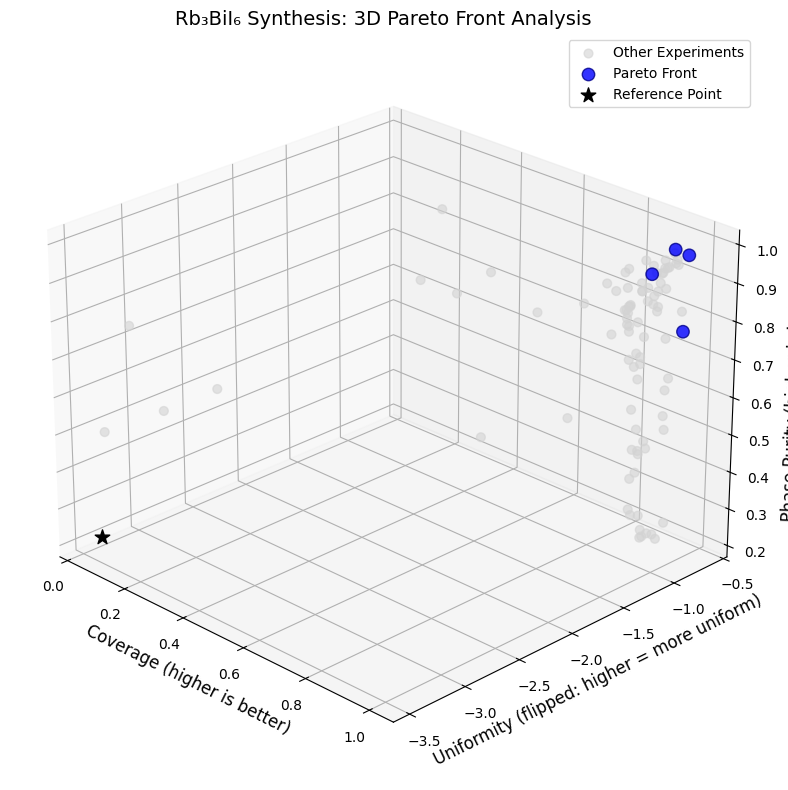


3D Pareto Analysis Summary:
• Total experiments: 90
• Pareto-optimal points: 4
• Proposed new experiments: 0
• Current hypervolume: 2.0120

✓ 3D visualization complete


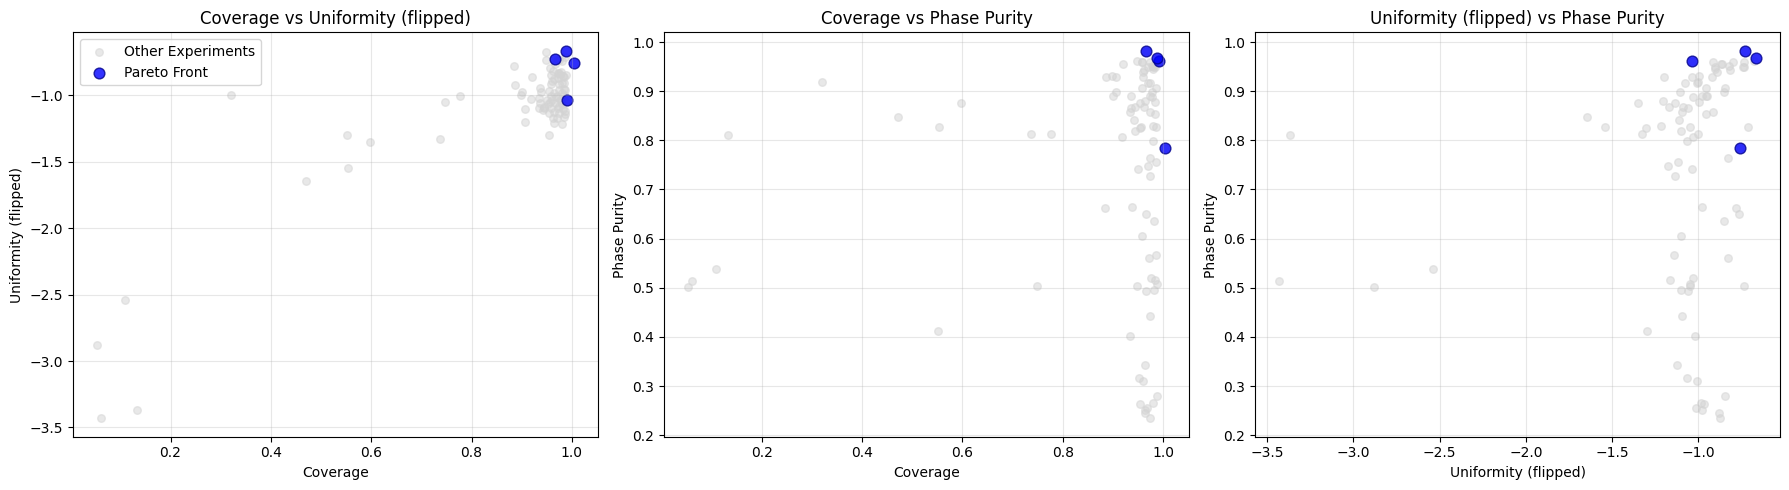

In [ ]:
# 3D Pareto front visualization and 2D projections
print("=== 3D Pareto Front Visualization ===")

maximize = [True, True, True]  # [Coverage, -Uniformity, Phase Purity]

def _flip_for_plot(Y_t, maximize_flags):
    Y_np = Y_t.detach().cpu().numpy().copy()
    for j, is_max in enumerate(maximize_flags):
        if not is_max:
            Y_np[:, j] = -Y_np[:, j]
    return Y_np

all_Y_np_plot = _flip_for_plot(Y_tensor, maximize)
pareto_Y_np_plot = _flip_for_plot(pareto_Y_t, maximize)
ref_point_np_plot = _flip_for_plot(ref_point_t.view(1, -1), maximize)

# Optional: predicted next experiments (if available)
next_Y_np_plot = None
if 'out' in globals() and out.get('success', False):
    Y_next_t = torch.FloatTensor(pred_mean).to(device)
    next_Y_np_plot = _flip_for_plot(Y_next_t, maximize)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot all points
non_pareto_mask = ~is_non_dominated(Y_tensor).cpu().numpy()
if non_pareto_mask.any():
    ax.scatter(
        all_Y_np_plot[non_pareto_mask, 0], 
        all_Y_np_plot[non_pareto_mask, 1], 
        all_Y_np_plot[non_pareto_mask, 2],
        c='lightgray', s=40, alpha=0.6, label='Other Experiments'
    )

# Pareto front
ax.scatter(
    pareto_Y_np_plot[:, 0], pareto_Y_np_plot[:, 1], pareto_Y_np_plot[:, 2],
    c='blue', s=80, label='Pareto Front', alpha=0.8, edgecolors='darkblue'
)

# Proposed experiments
if next_Y_np_plot is not None:
    ax.scatter(
        next_Y_np_plot[:, 0], next_Y_np_plot[:, 1], next_Y_np_plot[:, 2],
        c='red', s=100, marker='^', label='Proposed Experiments', 
        alpha=0.9, edgecolors='darkred'
    )

# Reference point
ax.scatter(
    ref_point_np_plot[0, 0], ref_point_np_plot[0, 1], ref_point_np_plot[0, 2],
    c='black', s=120, marker='*', label='Reference Point'
)

ax.set_xlabel('Coverage (higher is better)', fontsize=12)
ax.set_ylabel('Uniformity (flipped: higher = more uniform)', fontsize=12)
ax.set_zlabel('Phase Purity (higher is better)', fontsize=12)
ax.set_title('Rb₃BiI₆ Synthesis: 3D Pareto Front Analysis', fontsize=14)
ax.legend(loc='best')
ax.view_init(elev=25, azim=-45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n3D Pareto Analysis Summary:")
print(f"• Total experiments: {len(all_Y_np_plot)}")
print(f"• Pareto-optimal points: {len(pareto_Y_np_plot)}")
print(f"• Proposed new experiments: {len(next_Y_np_plot) if next_Y_np_plot is not None else 0}")
print(f"• Current hypervolume: {hv_val:.4f}")
print("\n✓ 3D visualization complete")

# 2D projections for each pair of objectives
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Coverage", "Uniformity (flipped)", "Phase Purity"]
pairs = [(0, 1), (0, 2), (1, 2)]
for i, (a, b) in enumerate(pairs):
    ax2d = axes[i]
    ax2d.scatter(all_Y_np_plot[:, a], all_Y_np_plot[:, b], c='lightgray', s=30, alpha=0.5, label='Other Experiments')
    ax2d.scatter(pareto_Y_np_plot[:, a], pareto_Y_np_plot[:, b], c='blue', s=60, label='Pareto Front', alpha=0.8, edgecolors='darkblue')
    if next_Y_np_plot is not None:
        ax2d.scatter(next_Y_np_plot[:, a], next_Y_np_plot[:, b], c='red', s=80, marker='^', label='Proposed', alpha=0.9, edgecolors='darkred')
    ax2d.set_xlabel(labels[a])
    ax2d.set_ylabel(labels[b])
    ax2d.set_title(f'{labels[a]} vs {labels[b]}')
    ax2d.grid(True, alpha=0.3)
    if i == 0:
        ax2d.legend()
plt.tight_layout()
plt.show()


In [11]:
def load_plt_setting():
    plt.style.use('seaborn-v0_8-white')
    mpl.rcParams['font.sans-serif'] = "Arial"
    mpl.rcParams['font.family'] = "sans-serif"
    mpl.rcParams['axes.linewidth'] = 2
    font = {'size': 32}
    mpl.rc('font', **font)
    mpl.rcParams['xtick.major.pad']='8'
    mpl.rcParams['ytick.major.pad']='8'
    plt.rcParams["font.weight"] = "normal"
    plt.rcParams["axes.labelweight"] = "normal"
    plt.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['axes.linewidth'] = 2

In [66]:
# ------------------------------------------------------------
# Define the two specific Pareto-front recipes to highlight
# ------------------------------------------------------------
labels = ["Coverage", "Uniformity", "Phase Purity Proxy"]

pred_cols = [
    "pred_coverage",
    "pred_uniformity",
    "pred_phase_purity"
]

std_cols = [
    "std_coverage",
    "std_uniformity",
    "std_phase_purity"
]
target_conditions = pd.DataFrame([
    [4000, 0.3, 260, 1, 3],
    [3500, 0.2, 250, 1, 3],
], columns=x_labels)

target_conditions["point_label"] = [
    "XRD-1\n4000 rpm, 0.3 M, 260 °C",
    "XRD-2\n3500 rpm, 0.2 M, 250 °C"
]

target_conditions["highlight_color"] = ["#791580", "#A0207B"]


def match_target_points(pareto_df, target_conditions, x_labels, atol=1e-8):
    """
    Find target recipes inside pareto_df based on processing parameters.
    Uses np.isclose to avoid floating-point mismatch.
    """
    matched_list = []

    for _, target in target_conditions.iterrows():
        mask = np.ones(len(pareto_df), dtype=bool)

        for col in x_labels:
            mask &= np.isclose(
                pareto_df[col].astype(float).values,
                float(target[col]),
                atol=atol
            )

        matched = pareto_df.loc[mask].copy()

        if len(matched) == 0:
            print("Warning: this target condition was not found on the predicted Pareto front:")
            print(target[x_labels].to_dict())
            continue

        matched["point_label"] = target["point_label"]
        matched["highlight_color"] = target["highlight_color"]

        matched_list.append(matched)

    if len(matched_list) == 0:
        return pd.DataFrame()

    return pd.concat(matched_list, ignore_index=True)


highlight_df = match_target_points(
    pareto_df=pareto_df,
    target_conditions=target_conditions,
    x_labels=x_labels
)

print("Highlighted Pareto-front points:")
display(highlight_df[x_labels + pred_cols + ["point_label"]])

Highlighted Pareto-front points:


,Spin Speed [rpm],Precursor Concentration [mol/L],Annealing Temperature [°C],Solvent Ratio,Solute Ratio,pred_coverage,pred_uniformity,pred_phase_purity,point_label
0,4000.0,0.3,260.0,1.0,3.0,0.969322,0.951344,0.954865,"XRD-1\n4000 rpm, 0.3 M, 260 °C"
1,3500.0,0.2,250.0,1.0,3.0,0.982525,0.743033,0.954587,"XRD-2\n3500 rpm, 0.2 M, 250 °C"


=== 2D Surrogate Landscape Heatmaps with Pareto Front Overlay ===


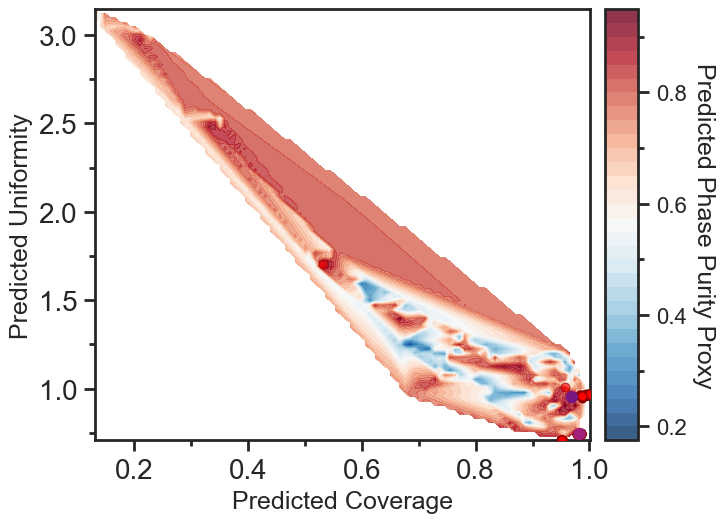

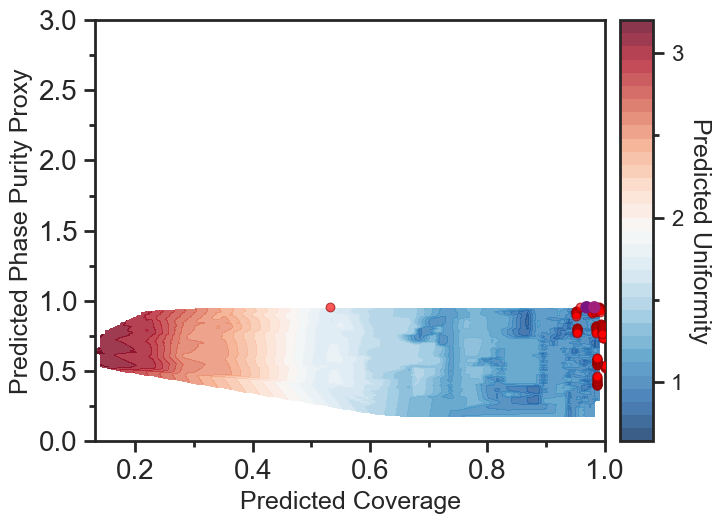

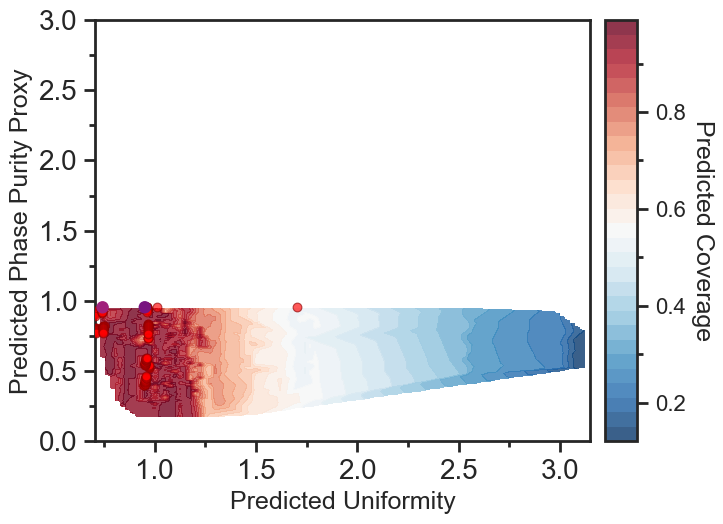

In [ ]:
print("=== 2D Surrogate Landscape Heatmaps with Pareto Front Overlay ===")

import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib as mpl
import numpy as np

labels = ["Coverage", "Uniformity", "Phase Purity Proxy"]
pred_cols = ["pred_coverage", "pred_uniformity", "pred_phase_purity"]
pairs = [(0, 1), (0, 2), (1, 2)]

for i, (a, b) in enumerate(pairs):
    load_plt_setting()

    fig, ax = plt.subplots(figsize=(8, 6))

    x = candidate_df[pred_cols[a]].values
    y = candidate_df[pred_cols[b]].values

    # Choose the third objective as heatmap color
    c_idx = [idx for idx in range(3) if idx not in (a, b)][0]
    c = candidate_df[pred_cols[c_idx]].values

    # Create grid for heatmap
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    xi, yi = np.meshgrid(xi, yi)

    ci = griddata((x, y), c, (xi, yi), method="linear")

    # Plot heatmap
    im = ax.contourf(xi, yi, ci,levels=30,cmap="RdBu_r",alpha=0.8)

    cbar = fig.colorbar(im, ax=ax, orientation="vertical", aspect=13, pad=0.025)
    cbar.set_label(f"Predicted {labels[c_idx]}",rotation=270,labelpad=20,fontsize=18)
    cbar.ax.tick_params(axis="y", direction="out", length=4, width=3, pad=5, labelsize=16)
    cbar.ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, integer=False, steps=[1, 2, 5, 10]))
    cbar.ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
    cbar.ax.tick_params(axis="both", which="major", direction="out", length=8, width=2, pad=5)
    cbar.ax.tick_params(axis="both", which="minor", direction="out", length=4, width=2, pad=5)

    # ------------------------------------------------------------
    # 1. Plot all predicted Pareto-front points
    # ------------------------------------------------------------
    ax.scatter(pareto_df[pred_cols[a]],pareto_df[pred_cols[b]],c="red",s=40,edgecolors="darkred",linewidths=0.8,alpha=0.65,zorder=3)

    # ------------------------------------------------------------
    # 2. Highlight the two selected XRD Pareto-front points
    # ------------------------------------------------------------
    if len(highlight_df) > 0:
        for j, row in highlight_df.iterrows():
            x0 = row[pred_cols[a]]
            y0 = row[pred_cols[b]]
            ax.scatter(x0,y0,s=80,c=row["highlight_color"],edgecolors="None",linewidths=0.8,zorder=3)

    # ------------------------------------------------------------
    # Axis formatting
    # ------------------------------------------------------------
    ax.set_xlabel(f"Predicted {labels[a]}", fontsize=18)
    ax.set_ylabel(f"Predicted {labels[b]}", fontsize=18)

    ax.tick_params(axis="both", direction="out", length=8, width=2, pad=5, labelsize=20)
    ax.tick_params(axis="both", which="minor", direction="out", length=4, width=2, pad=5)

    ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

    # Only force 0–3 ticks when phase-purity proxy is on the y-axis
    if pred_cols[b] == "pred_phase_purity":
        yticks = np.arange(0, 3.1, 0.5)
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{v:.1f}" for v in yticks], fontsize=20)

    # Do not use a standalone legend because labels are directly shown
    # ax.legend(fontsize=16)

    plt.tight_layout()
    plt.savefig(f'/Users/shengfang/Desktop/TRI/Rb3BiI6/Figure/pre_{labels[a]}_{labels[b]}.png',dpi=300, bbox_inches='tight')
    plt.savefig(f'/Users/shengfang/Desktop/TRI/Rb3BiI6/Figure/pre_{labels[a]}_{labels[b]}.svg',dpi=300, bbox_inches='tight')
    plt.show()

=== 2D Objective-Space GP Uncertainty Heatmaps with Pareto Front Overlay ===


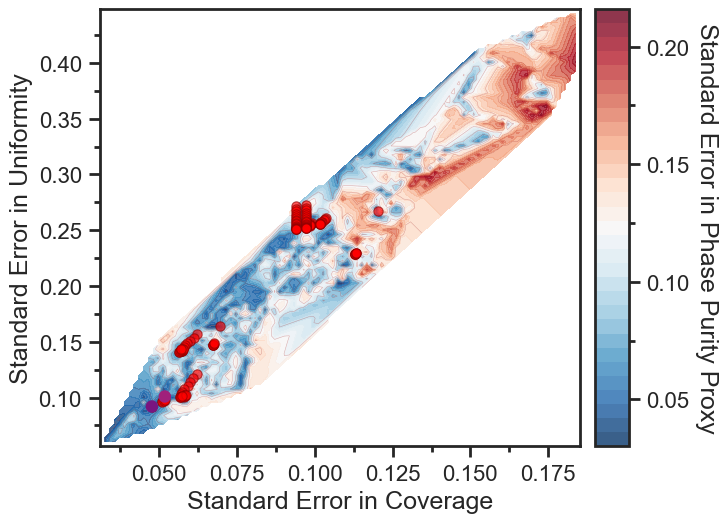

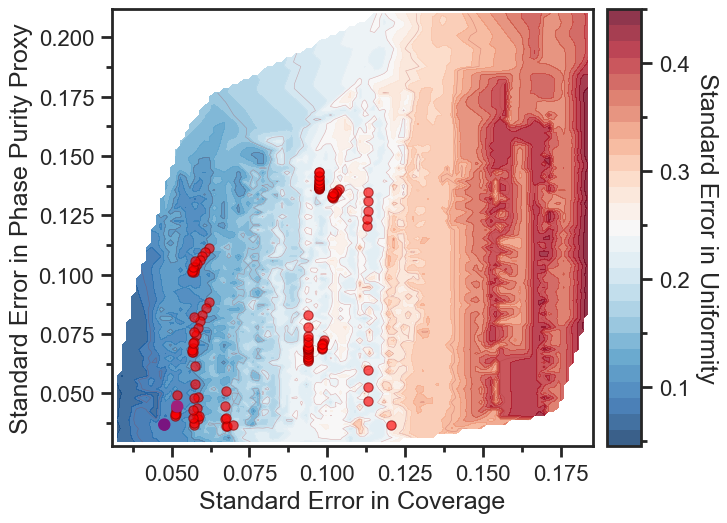

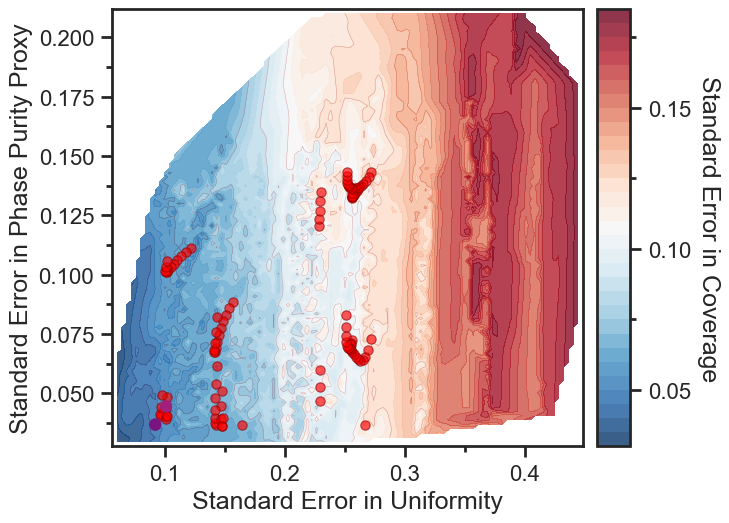

In [43]:
# ============================================================
# 2D objective-space uncertainty heatmaps
# x/y = predicted objectives
# color = GP posterior uncertainty in the third objective
# overlay = predicted Pareto front + highlighted XRD points
# ============================================================

print("=== 2D Objective-Space GP Uncertainty Heatmaps with Pareto Front Overlay ===")

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib as mpl

# ------------------------------------------------------------
# Objective labels and columns
# ------------------------------------------------------------

labels = ["Coverage", "Uniformity", "Phase Purity Proxy"]

pred_cols = [
    "pred_coverage",
    "pred_uniformity",
    "pred_phase_purity"
]

std_cols = [
    "std_coverage",
    "std_uniformity",
    "std_phase_purity"
]

pairs = [(0, 1), (0, 2), (1, 2)]

# ------------------------------------------------------------
# Plot each objective pair
# ------------------------------------------------------------

for i, (a, b) in enumerate(pairs):

    load_plt_setting()

    fig, ax = plt.subplots(figsize=(8, 6))

    # ------------------------------------------------------------
    # Create interpolated heatmap
    # ------------------------------------------------------------
    
    # Objective-space coordinates 
    x = candidate_df[std_cols[a]].values 
    y = candidate_df[std_cols[b]].values 
    # Choose the third objective uncertainty as color 
    c_idx = [idx for idx in range(3) if idx not in (a, b)][0] 
    c = candidate_df[std_cols[c_idx]].values
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    XI, YI = np.meshgrid(xi, yi)

    CI = griddata(
        points=(x, y),
        values=c,
        xi=(XI, YI),
        method="linear"
    )

    # ------------------------------------------------------------
    # Plot uncertainty heatmap
    # ------------------------------------------------------------

    im = ax.contourf(
        XI,
        YI,
        CI,
        levels=30,
        cmap="RdBu_r",
        alpha=0.8
    )

    # Optional contour lines
    ax.contour(
        XI,
        YI,
        CI,
        levels=10,
        colors="brown",
        linewidths=0.4,
        alpha=0.35
    )

    # ------------------------------------------------------------
    # Colorbar
    # ------------------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="vertical",
        aspect=13,
        pad=0.025
    )

    cbar.set_label(
        f"Standard Error in {labels[c_idx]}",
        rotation=270,
        labelpad=20,
        fontsize=18
    )

    cbar.ax.yaxis.set_major_locator(
        mpl.ticker.MaxNLocator(
            nbins=5,
            integer=False,
            steps=[1, 2, 5, 10]
        )
    )

    cbar.ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

    cbar.ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=8,
        width=2,
        pad=5,
        labelsize=16
    )

    cbar.ax.tick_params(
        axis="both",
        which="minor",
        direction="out",
        length=4,
        width=2,
        pad=5
    )

    # ------------------------------------------------------------
    # Overlay predicted Pareto front in objective space
    # ------------------------------------------------------------

    ax.scatter(
        pareto_df[std_cols[a]],
        pareto_df[std_cols[b]],
        c="red",
        s=45,
        edgecolors="darkred",
        linewidths=0.8,
        alpha=0.65,
        zorder=5
    )

    # ------------------------------------------------------------
    # Highlight selected XRD Pareto-front points
    # ------------------------------------------------------------

    if "highlight_df" in globals() and len(highlight_df) > 0:
        for j, row in highlight_df.iterrows():

            x0 = row[std_cols[a]]
            y0 = row[std_cols[b]]

            ax.scatter(
                x0,
                y0,
                s=80,
                c=row["highlight_color"],
                edgecolors="None",
                linewidths=1.5,
                zorder=8
            )

    # ------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------

    ax.set_xlabel(f"Standard Error in {labels[a]}", fontsize=18)
    ax.set_ylabel(f"Standard Error in {labels[b]}", fontsize=18)

    ax.tick_params(
        axis="both",
        direction="out",
        length=8,
        width=2,
        pad=5,
        labelsize=16
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="out",
        length=4,
        width=2,
        pad=5
    )

    ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

    plt.tight_layout()
    plt.savefig(f'/Users/shengfang/Desktop/TRI/Rb3BiI6/Figure/std_{labels[a]}_{labels[b]}.png',dpi=300, bbox_inches='tight')
    plt.savefig(f'/Users/shengfang/Desktop/TRI/Rb3BiI6/Figure/std_{labels[a]}_{labels[b]}.svg',dpi=300, bbox_inches='tight')
    plt.show()

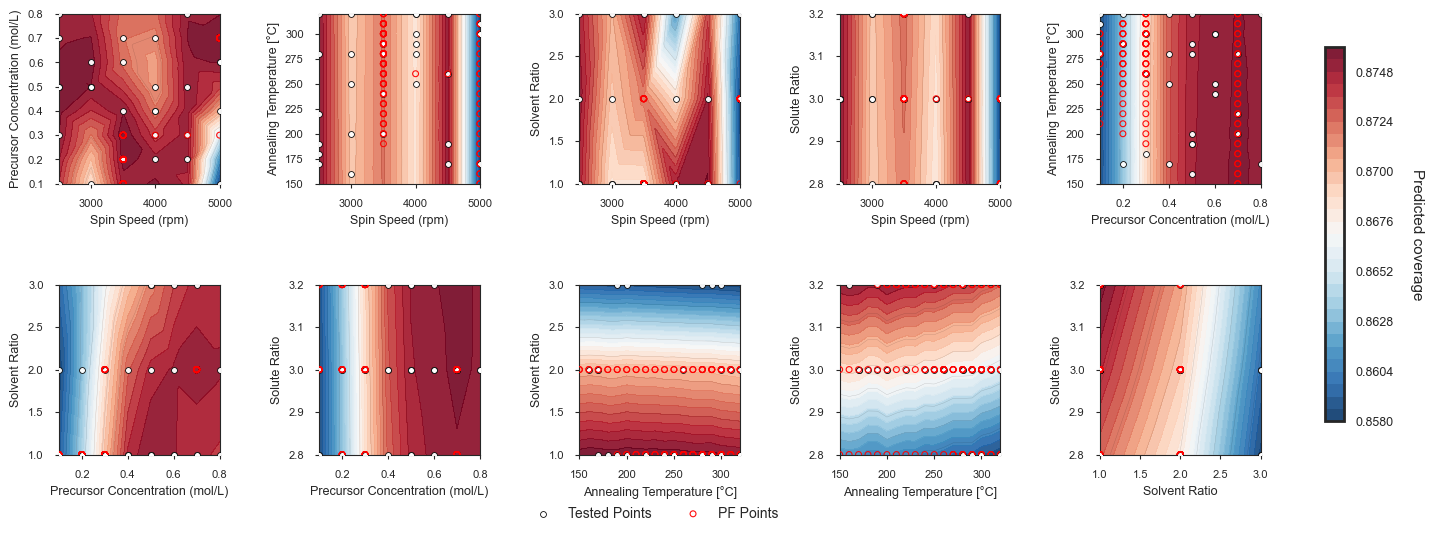

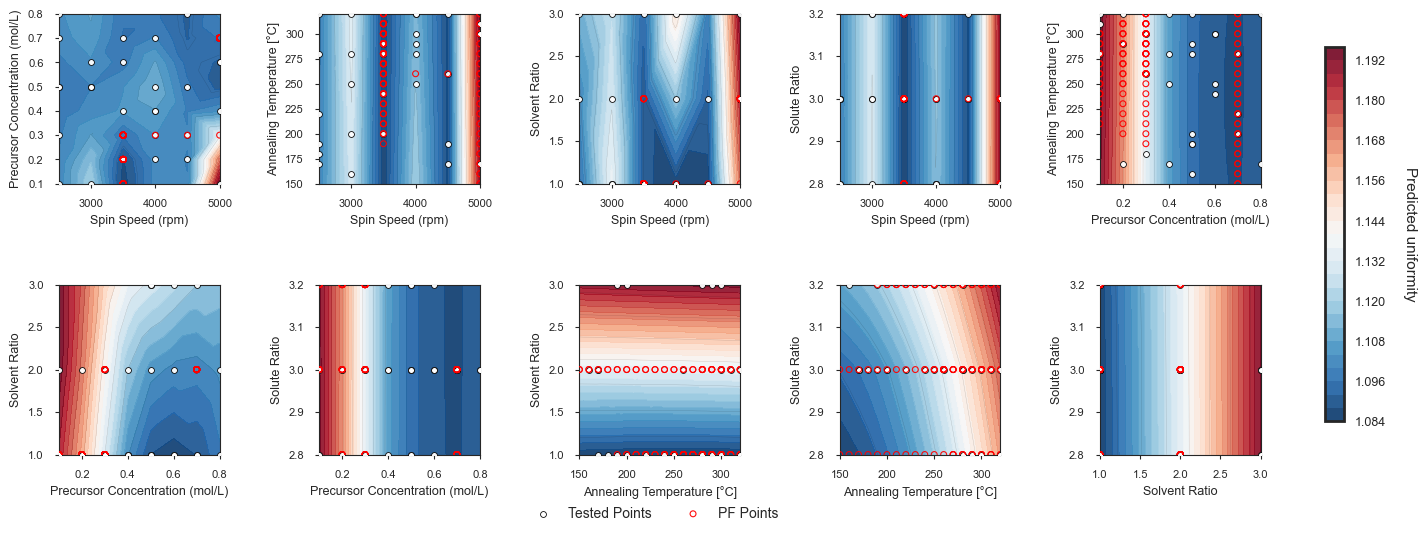

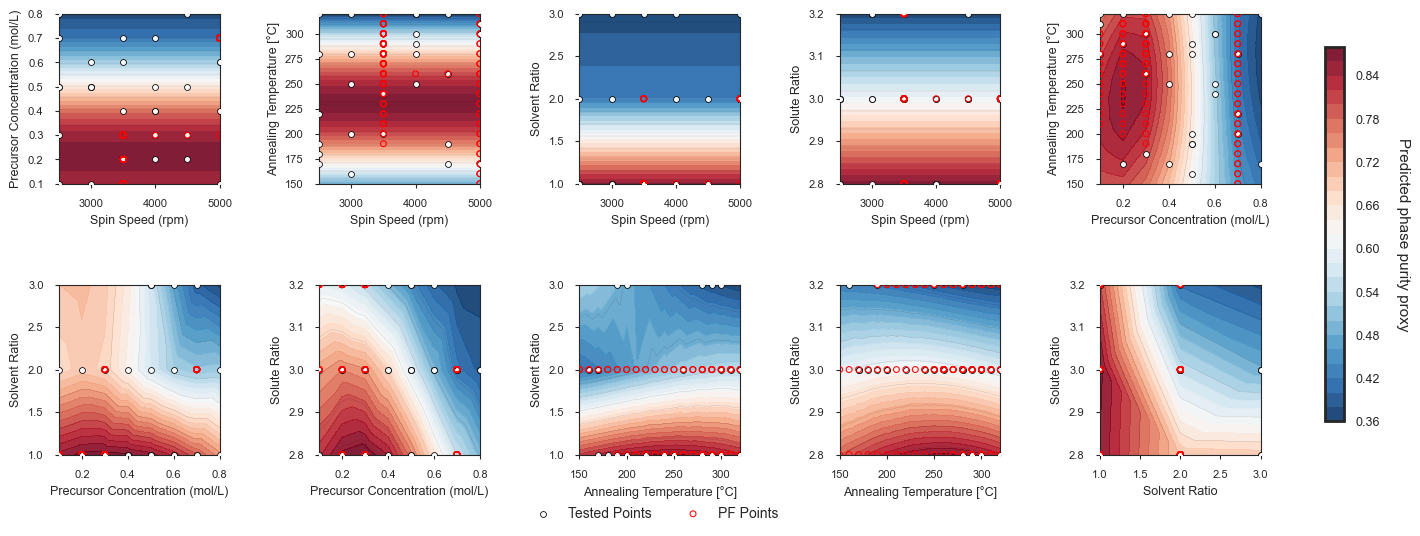

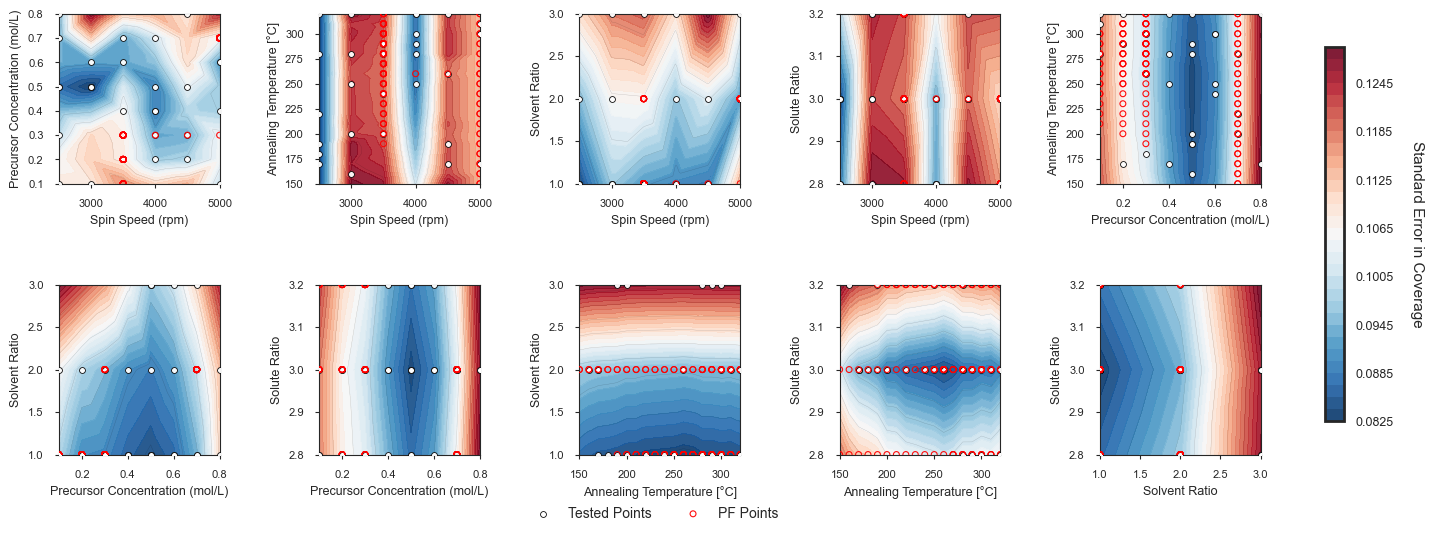

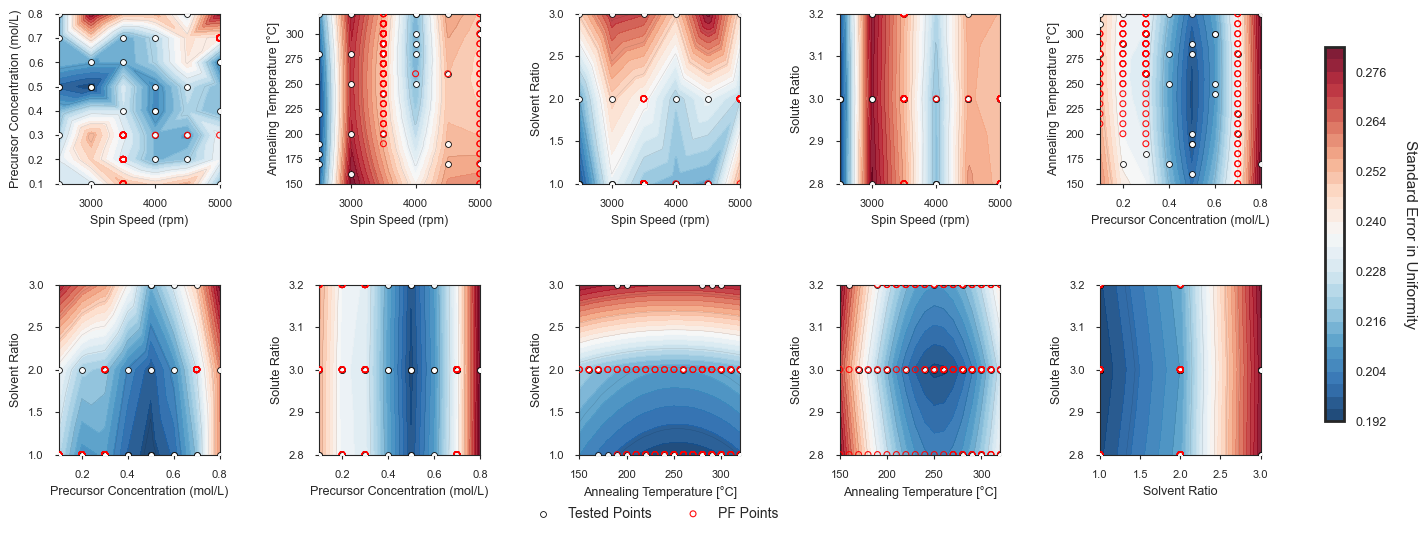

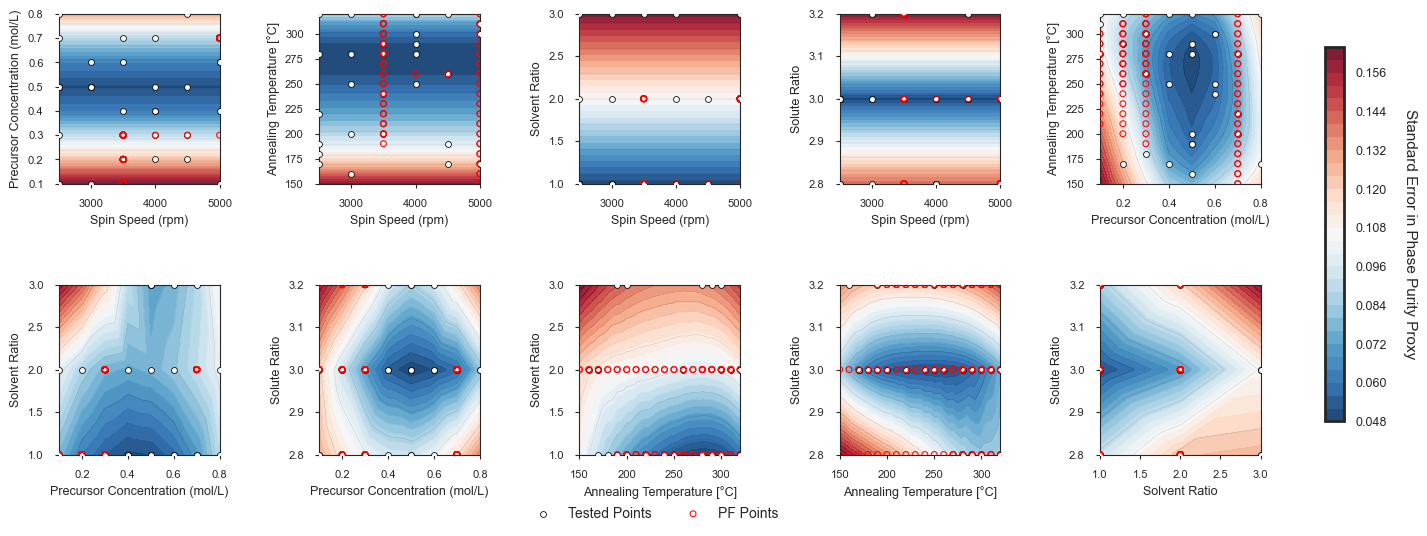

In [ ]:
# ============================================================
# Pairwise parameter-space maps for GP predicted values
# and GP posterior uncertainties
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.interpolate import griddata
from itertools import combinations

param_label_map = {
    "Spin Speed [rpm]": "Spin Speed (rpm)",
    "Precursor Concentration [mol/L]": "Precursor Concentration (mol/L)",
    "Annealing Temperature [degC]": "Annealing Temperature (°C)",
    "Solvent Ratio": "Solvent Ratio",
    "Solute Ratio": "Solute Ratio",
}


def plot_pairwise_parameter_maps(
    candidate_df,
    param_cols,
    value_col,
    value_label=None,
    tested_df=None,
    pareto_df=None,
    aggregate_method="mean",
    grid_n=120,
    cmap="RdBu_r",
    ncols=5,
    figsize_per_panel=(3.1, 2.8),
    savepath=None,
    show_tested=True,
    show_pareto=True,
    shared_colorbar=False,
    contour_lines=True,
    marker_size_tested=18,
    marker_size_pareto=18,
):
    """
    Pairwise 2D parameter-space projection plot.

    For each pair of design variables, the remaining hidden dimensions
    are aggregated using aggregate_method.

    Parameters
    ----------
    candidate_df : pd.DataFrame
        Full candidate grid with design variables and value_col.

    param_cols : list[str]
        Design-variable column names.

    value_col : str
        Column to visualize as color.

    value_label : str
        Colorbar label.

    aggregate_method : str
        How to collapse hidden dimensions.
        Options: "mean", "median", "max", "min".

    tested_df : pd.DataFrame
        Experimentally tested samples.

    pareto_df : pd.DataFrame
        Predicted Pareto candidates.

    savepath : str or None
        If provided, saves the figure.
    """

    pairs = list(combinations(param_cols, 2))
    n_panels = len(pairs)
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False
    )

    axes_flat = axes.ravel()

    # Shared color scale across panels
    if shared_colorbar:
        vmin = candidate_df[value_col].min()
        vmax = candidate_df[value_col].max()
    else:
        vmin, vmax = None, None

    last_im = None

    for idx, (x_col, y_col) in enumerate(pairs):
        ax = axes_flat[idx]

        # ----------------------------------------------------
        # Aggregate over hidden dimensions
        # ----------------------------------------------------
        if aggregate_method == "mean":
            df_pair = (
                candidate_df
                .groupby([x_col, y_col], as_index=False)[value_col]
                .mean()
            )
        elif aggregate_method == "median":
            df_pair = (
                candidate_df
                .groupby([x_col, y_col], as_index=False)[value_col]
                .median()
            )
        elif aggregate_method == "max":
            df_pair = (
                candidate_df
                .groupby([x_col, y_col], as_index=False)[value_col]
                .max()
            )
        elif aggregate_method == "min":
            df_pair = (
                candidate_df
                .groupby([x_col, y_col], as_index=False)[value_col]
                .min()
            )
        else:
            raise ValueError(
                "aggregate_method must be one of: 'mean', 'median', 'max', 'min'."
            )

        x = df_pair[x_col].values
        y = df_pair[y_col].values
        z = df_pair[value_col].values

        # ----------------------------------------------------
        # Interpolate onto regular 2D grid
        # ----------------------------------------------------
        xi = np.linspace(x.min(), x.max(), grid_n)
        yi = np.linspace(y.min(), y.max(), grid_n)
        XI, YI = np.meshgrid(xi, yi)

        ZI = griddata(
            points=(x, y),
            values=z,
            xi=(XI, YI),
            method="linear"
        )

        # If linear interpolation gives too many NaNs, fill with nearest.
        if np.isnan(ZI).mean() > 0.25:
            ZI_nearest = griddata(
                points=(x, y),
                values=z,
                xi=(XI, YI),
                method="nearest"
            )
            ZI = np.where(np.isnan(ZI), ZI_nearest, ZI)

        # ----------------------------------------------------
        # Heatmap
        # ----------------------------------------------------
        last_im = ax.contourf(
            XI,
            YI,
            ZI,
            levels=30,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            alpha=0.90
        )

        if contour_lines:
            ax.contour(
                XI,
                YI,
                ZI,
                levels=8,
                colors="k",
                linewidths=0.25,
                alpha=0.22
            )

        # ----------------------------------------------------
        # Overlay predicted Pareto candidates
        # ----------------------------------------------------
        if (
            show_pareto
            and pareto_df is not None
            and len(pareto_df) > 0
            and x_col in pareto_df.columns
            and y_col in pareto_df.columns
        ):
            ax.scatter(
                pareto_df[x_col],
                pareto_df[y_col],
                s=marker_size_pareto,
                facecolors="none",
                edgecolors="red",
                linewidths=0.8,
                alpha=0.95,
                label="PF Points",
                zorder=5
            )

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------
        ax.set_xlabel(param_label_map.get(x_col, x_col), fontsize=9)
        ax.set_ylabel(param_label_map.get(y_col, y_col), fontsize=9)

        ax.tick_params(
            axis="both",
            direction="out",
            length=3,
            width=0.8,
            labelsize=8
        )

        ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    # Hide unused axes
    for j in range(n_panels, len(axes_flat)):
        axes_flat[j].axis("off")
    plt.tight_layout()
    fig.subplots_adjust(right=0.90, bottom=0.12)


    # --------------------------------------------------------
    # Shared colorbar
    # --------------------------------------------------------
    if value_label is None:
        value_label = value_col
    
    cbar = fig.colorbar(
        last_im,
        ax=axes_flat[:n_panels],
        orientation="vertical",
        fraction=0.02,    # thickness relative to the axes group
        pad=0.05,         # gap between panels and colorbar
        shrink=0.85        # shrink height so it doesn't span edge-to-edge
    )
    cbar.set_label(value_label, rotation=270, labelpad=22, fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Shared legend
    # --------------------------------------------------------
    handles, legend_labels = axes_flat[0].get_legend_handles_labels()

    if handles:
        unique = dict(zip(legend_labels, handles))
        fig.legend(
            unique.values(),
            unique.keys(),
            loc="lower center",
            ncol=len(unique),
            frameon=False,
            fontsize=10,
            bbox_to_anchor=(0.45, -0.02),
        )

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


# ------------------------------------------------------------
# Generate predicted-objective maps
# ------------------------------------------------------------

plot_pairwise_parameter_maps(
    candidate_df=candidate_df,
    param_cols=x_labels,
    value_col="pred_coverage",
    value_label="Predicted coverage",
    tested_df=tested_df,
    pareto_df=pareto_df,
    aggregate_method="mean",
    cmap="RdBu_r",
    ncols=5,
)

plot_pairwise_parameter_maps(
    candidate_df=candidate_df,
    param_cols=x_labels,
    value_col="pred_uniformity",
    value_label="Predicted uniformity",
    tested_df=tested_df,
    pareto_df=pareto_df,
    aggregate_method="mean",
    cmap="RdBu_r",
    ncols=5,
)

plot_pairwise_parameter_maps(
    candidate_df=candidate_df,
    param_cols=x_labels,
    value_col="pred_phase_purity",
    value_label="Predicted phase purity proxy",
    tested_df=tested_df,
    pareto_df=pareto_df,
    aggregate_method="mean",
    cmap="RdBu_r",
    ncols=5,
)


# ------------------------------------------------------------
#  Generate uncertainty maps
# ------------------------------------------------------------

plot_pairwise_parameter_maps(
    candidate_df=candidate_df,
    param_cols=x_labels,
    value_col="std_coverage",
    value_label="Standard Error in Coverage",
    tested_df=tested_df,
    pareto_df=pareto_df,
    aggregate_method="mean",
    cmap="RdBu_r",
    ncols=5,
)

plot_pairwise_parameter_maps(
    candidate_df=candidate_df,
    param_cols=x_labels,
    value_col="std_uniformity",
    value_label="Standard Error in Uniformity",
    tested_df=tested_df,
    pareto_df=pareto_df,
    aggregate_method="mean",
    cmap="RdBu_r",
    ncols=5,
)

plot_pairwise_parameter_maps(
    candidate_df=candidate_df,
    param_cols=x_labels,
    value_col="std_phase_purity",
    value_label="Standard Error in Phase Purity Proxy",
    tested_df=tested_df,
    pareto_df=pareto_df,
    aggregate_method="mean",
    cmap="RdBu_r",
    ncols=5,
)
